# Cellula Technologies - LSTM Text Classification

## Task 2 - Final Submission

This notebook contains the complete preprocessing, data-quality audit,
training, evaluation, and reporting workflow for the **Long Short-Term Memory (LSTM)** task.

**Assignment target:** F1-score >= 0.85

> Dataset limitation: the supplied data contains substantial duplicate and
> template-like content. The notebook measures and reports this overlap so the
> benchmark result is interpreted transparently.

## 1. Environment Setup

In [1]:
# ============================================================
# IMPORT LIBRARIES AND SET RANDOM SEEDS
# ============================================================

import os
import re
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    SimpleRNN,
    LSTM,
    Bidirectional,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.20.0
GPU available: False


## 2. Project Configuration

In [2]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

# Expected dataset path in Google Colab
DATA_PATH = "/content/cellula toxic data  (1).csv"

# Tokenizer
MAX_WORDS = 15000

# Model sizes
EMBEDDING_DIM = 128
RNN_UNITS = 128
LSTM_UNITS = 128

# Training
BATCH_SIZE = 32
MAX_EPOCHS = 35
LEARNING_RATE = 5e-4

# Assignment targets
RNN_F1_TARGET = 0.75
LSTM_F1_TARGET = 0.85

print("Configuration loaded successfully.")

Configuration loaded successfully.


## 3. Load the Dataset

In [3]:
# ============================================================
# LOAD THE CSV FILE
# ============================================================

# If the dataset is not already in /content, Colab asks for it.
if not os.path.exists(DATA_PATH):
    from google.colab import files

    print("Dataset not found in /content.")
    print("Please upload the Cellula CSV file.")

    uploaded = files.upload()
    DATA_PATH = next(iter(uploaded.keys()))

# Read the original dataset
df_raw = pd.read_csv(DATA_PATH)

# Work on a copy so the original file remains untouched
df = df_raw.copy()

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Dataset not found in /content.
Please upload the Cellula CSV file.


Saving cellula toxic data  (1).csv to cellula toxic data  (1).csv
Dataset loaded successfully.
Shape: (3000, 3)
Columns: ['query', 'image descriptions', 'Toxic Category']


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


## 4. Data Quality Audit

The dataset is checked for the main issues discovered during exploration:

- class imbalance,
- exact duplicate records,
- repeated queries,
- large template-generated groups,
- repeated / generic image descriptions,
- and possible label noise.

These limitations are documented before training so the final benchmark can be interpreted correctly.

In [4]:
# ============================================================
# BASIC DATA QUALITY CHECKS
# ============================================================

required_columns = [
    "query",
    "image descriptions",
    "Toxic Category"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Convert required columns safely to strings
for col in required_columns:
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# Remove only unusable rows
before_filtering = len(df)

df = df[
    (df["query"] != "") &
    (df["Toxic Category"] != "")
].copy()

print("Rows before filtering:", before_filtering)
print("Rows after filtering :", len(df))

# Missing values
print("\nMissing values:")
display(df[required_columns].isna().sum())

# Class distribution
print("\nClass distribution:")
class_distribution = df["Toxic Category"].value_counts()
display(class_distribution)

# Exact duplicates
exact_duplicate_count = df.duplicated(
    subset=[
        "query",
        "image descriptions",
        "Toxic Category"
    ]
).sum()

print("\nExact duplicate rows:", int(exact_duplicate_count))

# Repeated queries
repeated_query_rows = df.duplicated(
    subset=["query"],
    keep=False
).sum()

print(
    "Rows belonging to repeated-query groups:",
    int(repeated_query_rows)
)

# Image-description diversity
print(
    "Unique image descriptions:",
    df["image descriptions"].nunique()
)

Rows before filtering: 3000
Rows after filtering : 3000

Missing values:


,0
query,0
image descriptions,0
Toxic Category,0



Class distribution:


,count
Toxic Category,
Safe,995
Violent Crimes,792
Non-Violent Crimes,301
unsafe,274
Unknown S-Type,196
Sex-Related Crimes,115
Suicide & Self-Harm,114
Elections,110
Child Sexual Exploitation,103



Exact duplicate rows: 973
Rows belonging to repeated-query groups: 1000
Unique image descriptions: 12


In [5]:
# ============================================================
# DETECT KNOWN TEMPLATE-LIKE PATTERNS
# ============================================================
#
# Two very large synthetic patterns were discovered during
# exploratory analysis.
#
# IMPORTANT:
# The rows are FLAGGED for transparency but are NOT deleted in
# this assignment benchmark notebook.
# ============================================================

health_template_mask = (
    df["query"]
    .str.contains(
        "What are the health benefits of daily exercise",
        case=False,
        na=False
    )
)

activity_template_mask = (
    df["query"]
    .str.contains(
        "Explain how to perform an activity related to",
        case=False,
        na=False
    )
)

df["is_known_template"] = (
    health_template_mask |
    activity_template_mask
)

template_count = int(df["is_known_template"].sum())

print("Known template-like rows:", template_count)
print(
    "Template percentage:",
    f"{template_count / len(df) * 100:.2f}%"
)

print("\nTemplate rows by class:")
display(
    df.loc[
        df["is_known_template"],
        "Toxic Category"
    ].value_counts()
)

Known template-like rows: 1000
Template percentage: 33.33%

Template rows by class:


,count
Toxic Category,
unsafe,134
Safe,117
Sex-Related Crimes,114
Unknown S-Type,113
Suicide & Self-Harm,112
Elections,109
Violent Crimes,102
Child Sexual Exploitation,102
Non-Violent Crimes,97


### Audit Interpretation

The dataset contains substantial repetition and template-like content.  
A random split can therefore place identical or highly similar examples in both training and test partitions.

For transparency, this notebook:

- reports the overlap explicitly,
- keeps the supplied rows for the assignment benchmark,
- does **not** use external pseudo-labeling,
- and does not present the benchmark as a leakage-free real-world estimate.

## 5. Text Preprocessing

In [6]:
# ============================================================
# LIGHT TEXT CLEANING
# ============================================================
#
# Cleaning steps:
# - lowercase
# - remove URLs
# - remove simple HTML fragments
# - remove unnecessary symbols
# - normalize whitespace
#
# Aggressive stemming/lemmatization is intentionally avoided.
# ============================================================

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove simple HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep letters, numbers, spaces, and apostrophes
    text = re.sub(r"[^a-z0-9\s']", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["query_clean"] = df["query"].apply(clean_text)

df["image_clean"] = (
    df["image descriptions"]
    .apply(clean_text)
)

# ------------------------------------------------------------
# Combine the two textual columns.
#
# Explicit field markers allow the sequence model to distinguish
# the query from the image description.
# ------------------------------------------------------------
df["model_text"] = (
    "query " +
    df["query_clean"] +
    " image description " +
    df["image_clean"]
)

print("Example original query:")
print(df["query"].iloc[0])

print("\nExample model input:")
print(df["model_text"].iloc[0])

Example original query:
What is the right way to handle a severe head injury?

Example model input:
query what is the right way to handle a severe head injury image description a child playing in a sunny meadow


## 6. Stratified Train / Validation / Test Split

In [7]:
# ============================================================
# STRATIFIED 80 / 10 / 10 SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["Toxic Category"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["Toxic Category"]
)

print("Train rows     :", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows      :", len(test_df))

print("\nTraining distribution:")
display(train_df["Toxic Category"].value_counts())

print("\nValidation distribution:")
display(val_df["Toxic Category"].value_counts())

print("\nTest distribution:")
display(test_df["Toxic Category"].value_counts())

Train rows     : 2400
Validation rows: 300
Test rows      : 300

Training distribution:


,count
Toxic Category,
Safe,796
Violent Crimes,634
Non-Violent Crimes,241
unsafe,219
Unknown S-Type,157
Sex-Related Crimes,92
Suicide & Self-Harm,91
Elections,88
Child Sexual Exploitation,82



Validation distribution:


,count
Toxic Category,
Safe,99
Violent Crimes,79
Non-Violent Crimes,30
unsafe,27
Unknown S-Type,20
Sex-Related Crimes,12
Suicide & Self-Harm,11
Elections,11
Child Sexual Exploitation,11



Test distribution:


,count
Toxic Category,
Safe,100
Violent Crimes,79
Non-Violent Crimes,30
unsafe,28
Unknown S-Type,19
Suicide & Self-Harm,12
Elections,11
Sex-Related Crimes,11
Child Sexual Exploitation,10


### 6.1 Split Leakage Diagnostic

In [8]:
# ============================================================
# MEASURE EXACT INPUT OVERLAP ACROSS SPLITS
# ============================================================
#
# This cell does NOT modify the benchmark.
# It measures the leakage risk caused by repeated inputs.
# ============================================================

train_inputs = set(train_df["model_text"])

val_overlap_mask = (
    val_df["model_text"]
    .isin(train_inputs)
)

test_overlap_mask = (
    test_df["model_text"]
    .isin(train_inputs)
)

val_overlap_count = int(val_overlap_mask.sum())
test_overlap_count = int(test_overlap_mask.sum())

print(
    "Validation rows with an exact input already in Train:",
    val_overlap_count,
    f"({val_overlap_count / len(val_df) * 100:.2f}%)"
)

print(
    "Test rows with an exact input already in Train:",
    test_overlap_count,
    f"({test_overlap_count / len(test_df) * 100:.2f}%)"
)

print(
    "\nInterpretation: benchmark metrics can be optimistic because "
    "the supplied dataset contains repeated/template-like inputs."
)

Validation rows with an exact input already in Train: 90 (30.00%)
Test rows with an exact input already in Train: 114 (38.00%)

Interpretation: benchmark metrics can be optimistic because the supplied dataset contains repeated/template-like inputs.


## 7. Label Encoding

In [9]:
# ============================================================
# ENCODE TEXT LABELS AS INTEGER CLASS IDs
# ============================================================

label_encoder = LabelEncoder()

label_encoder.fit(
    df["Toxic Category"]
)

y_train = label_encoder.transform(
    train_df["Toxic Category"]
)

y_val = label_encoder.transform(
    val_df["Toxic Category"]
)

y_test = label_encoder.transform(
    test_df["Toxic Category"]
)

NUM_CLASSES = len(label_encoder.classes_)

print("Label mapping:\n")

for class_id, label in enumerate(
    label_encoder.classes_
):
    print(class_id, "->", label)

print("\nNumber of classes:", NUM_CLASSES)

Label mapping:

0 -> Child Sexual Exploitation
1 -> Elections
2 -> Non-Violent Crimes
3 -> Safe
4 -> Sex-Related Crimes
5 -> Suicide & Self-Harm
6 -> Unknown S-Type
7 -> Violent Crimes
8 -> unsafe

Number of classes: 9


## 8. Tokenization and Padding

In [10]:
# ============================================================
# TOKENIZATION
# ============================================================
#
# IMPORTANT:
# The tokenizer is fitted on TRAINING DATA ONLY.
# This prevents vocabulary leakage from validation/test data.
# ============================================================

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    train_df["model_text"]
)

# Select a sequence length from training data only
train_word_lengths = (
    train_df["model_text"]
    .str.split()
    .str.len()
)

MAX_LEN = int(
    np.percentile(
        train_word_lengths,
        98
    )
)

MAX_LEN = int(
    np.clip(
        MAX_LEN,
        30,
        120
    )
)

def encode_and_pad(text_series):
    # Convert text to token IDs
    sequences = tokenizer.texts_to_sequences(
        text_series
    )

    # Pad/truncate every sequence to MAX_LEN
    return pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

X_train = encode_and_pad(
    train_df["model_text"]
)

X_val = encode_and_pad(
    val_df["model_text"]
)

X_test = encode_and_pad(
    test_df["model_text"]
)

VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size :", VOCAB_SIZE)
print("Sequence length :", MAX_LEN)

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Vocabulary size : 3972
Sequence length : 44

X_train: (2400, 44)
y_train: (2400,)
X_val  : (300, 44)
y_val  : (300,)
X_test : (300, 44)
y_test : (300,)


## 9. Handling Class Imbalance

In [11]:
# ============================================================
# COMPUTE MODERATE CLASS WEIGHTS
# ============================================================
#
# The dataset is imbalanced.
# Minority-class errors should matter more during training.
#
# Extremely large weights can destabilize optimization, so the
# balanced weights are clipped to the range [0.6, 3.0].
# ============================================================

unique_classes = np.unique(y_train)

raw_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=y_train
)

class_weights = {
    int(class_id): float(
        np.clip(
            weight,
            0.6,
            3.0
        )
    )

    for class_id, weight
    in zip(
        unique_classes,
        raw_class_weights
    )
}

print("Class weights:\n")

for class_id, weight in class_weights.items():

    label = label_encoder.inverse_transform(
        [class_id]
    )[0]

    print(
        f"{class_id} -> {label}: {weight:.3f}"
    )

Class weights:

0 -> Child Sexual Exploitation: 3.000
1 -> Elections: 3.000
2 -> Non-Violent Crimes: 1.107
3 -> Safe: 0.600
4 -> Sex-Related Crimes: 2.899
5 -> Suicide & Self-Harm: 2.930
6 -> Unknown S-Type: 1.699
7 -> Violent Crimes: 0.600
8 -> unsafe: 1.218


## 10. Majority-Class Baseline

In [12]:
# ============================================================
# SIMPLE BASELINE
# ============================================================
#
# This baseline predicts the most common training class for
# every test example.
# ============================================================

majority_class_id = (
    pd.Series(y_train)
    .value_counts()
    .idxmax()
)

majority_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class_id
)

majority_accuracy = accuracy_score(
    y_test,
    majority_predictions
)

majority_macro_f1 = f1_score(
    y_test,
    majority_predictions,
    average="macro",
    zero_division=0
)

print(
    "Majority-class baseline accuracy:",
    round(majority_accuracy, 4)
)

print(
    "Majority-class baseline Macro F1:",
    round(majority_macro_f1, 4)
)

Majority-class baseline accuracy: 0.3333
Majority-class baseline Macro F1: 0.0556


## 11. Shared Training and Evaluation Utilities

In [13]:
# ============================================================
# CALLBACKS
# ============================================================

def make_callbacks(model_path):

    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        ModelCheckpoint(
            model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        )
    ]


# ============================================================
# TRAINING CURVES
# ============================================================

def plot_history(
    history,
    model_name,
    file_prefix
):

    # Accuracy curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"{model_name} — Training vs Validation Accuracy"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"/content/{file_prefix}_accuracy.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


    # Loss curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{model_name} — Training vs Validation Loss"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"/content/{file_prefix}_loss.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# FINAL TEST EVALUATION
# ============================================================

def evaluate_model(
    model,
    X,
    y,
    model_name,
    file_prefix
):

    probabilities = model.predict(
        X,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y,
        predictions
    )

    macro_f1 = f1_score(
        y,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y,
        predictions,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 75)
    print(model_name)
    print("=" * 75)

    print("Accuracy   :", round(accuracy, 4))
    print("Macro F1   :", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))

    print("\nClassification Report:\n")

    report_text = classification_report(
        y,
        predictions,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )

    print(report_text)

    # Save the classification report as CSV
    report_dict = classification_report(
        y,
        predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(
        report_dict
    ).transpose().to_csv(
        f"/content/{file_prefix}_classification_report.csv"
    )

    # Confusion matrix
    cm = confusion_matrix(
        y,
        predictions
    )

    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    display_cm.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"{model_name} — Confusion Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        f"/content/{file_prefix}_confusion_matrix.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    metrics = {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    return metrics, predictions

# Task 2 — Long Short-Term Memory (LSTM)

The same preprocessing and evaluation pipeline is reused to keep the comparison fair.

The main architectural change is replacing the `SimpleRNN` layer with a **Bidirectional LSTM**.

In [18]:
# ============================================================
# BUILD THE LSTM MODEL
# ============================================================

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

lstm_model = Sequential(
    [
        Input(
            shape=(MAX_LEN,)
        ),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True
        ),

        SpatialDropout1D(
            0.15
        ),

        Bidirectional(
            LSTM(
                LSTM_UNITS,
                return_sequences=True,
                dropout=0.15
            )
        ),

        GlobalMaxPooling1D(),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(
            0.30
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ],
    name="Cellula_LSTM"
)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

lstm_model.summary()

Model: "Cellula_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 44, 128)        │       508,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 44, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 44, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,641 (3.07 MB)

 Trainable params: 805,641 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# TRAIN THE LSTM MODEL
# ============================================================

lstm_history = lstm_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=MAX_EPOCHS,

    batch_size=BATCH_SIZE,

    class_weight=class_weights,

    callbacks=make_callbacks(
        "/content/cellula_lstm.keras"
    ),

    verbose=1
)

Epoch 1/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.4371 - loss: 2.1253 - val_accuracy: 0.6667 - val_loss: 0.8858 - learning_rate: 5.0000e-04
Epoch 2/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.7425 - loss: 1.2030 - val_accuracy: 0.8700 - val_loss: 0.5269 - learning_rate: 5.0000e-04
Epoch 3/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 173ms/step - accuracy: 0.8854 - loss: 0.6717 - val_accuracy: 0.9467 - val_loss: 0.2750 - learning_rate: 5.0000e-04
Epoch 4/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.9513 - loss: 0.3063 - val_accuracy: 0.9467 - val_loss: 0.2085 - learning_rate: 5.0000e-04
Epoch 5/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.9700 - loss: 0.1978 - val_accuracy: 0.9533 - val_loss: 0.1507 - learning_rate: 5.0000e-04
Epoch 6/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.9804 - loss: 0.1161 - val_accuracy: 0.9000 - val_loss: 0.2775 - learning_rate: 5.0000e-04
Epoch 7/35
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accu

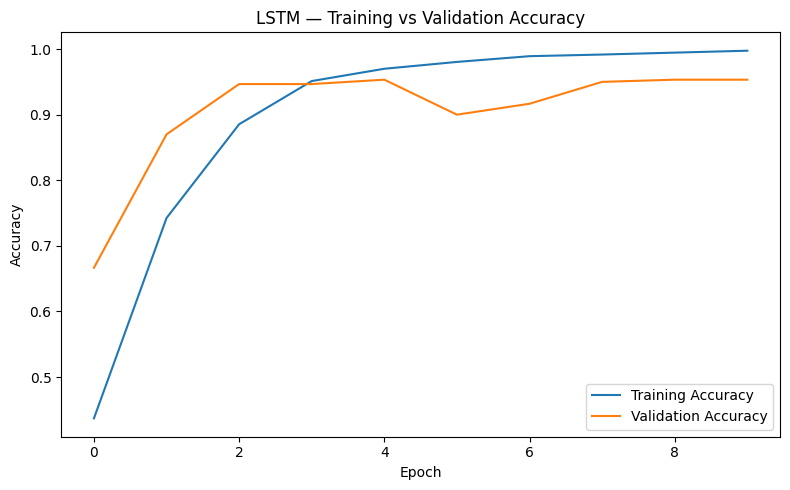

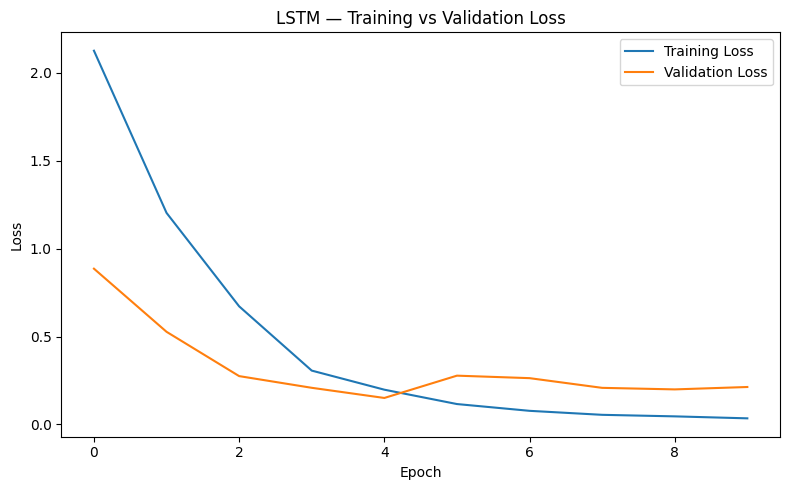

In [20]:
# ============================================================
# LSTM TRAINING CURVES
# ============================================================

plot_history(
    lstm_history,
    model_name="LSTM",
    file_prefix="lstm"
)


LSTM
Accuracy   : 0.9533
Macro F1   : 0.9504
Weighted F1: 0.9513

Classification Report:

                           precision    recall  f1-score   support

Child Sexual Exploitation     1.0000    1.0000    1.0000        10
                Elections     1.0000    1.0000    1.0000        11
       Non-Violent Crimes     1.0000    0.9667    0.9831        30
                     Safe     0.9223    0.9500    0.9360       100
       Sex-Related Crimes     1.0000    1.0000    1.0000        11
      Suicide & Self-Harm     1.0000    1.0000    1.0000        12
           Unknown S-Type     0.7333    0.5789    0.6471        19
           Violent Crimes     0.9753    1.0000    0.9875        79
                   unsafe     1.0000    1.0000    1.0000        28

                 accuracy                         0.9533       300
                macro avg     0.9590    0.9440    0.9504       300
             weighted avg     0.9507    0.9533    0.9513       300



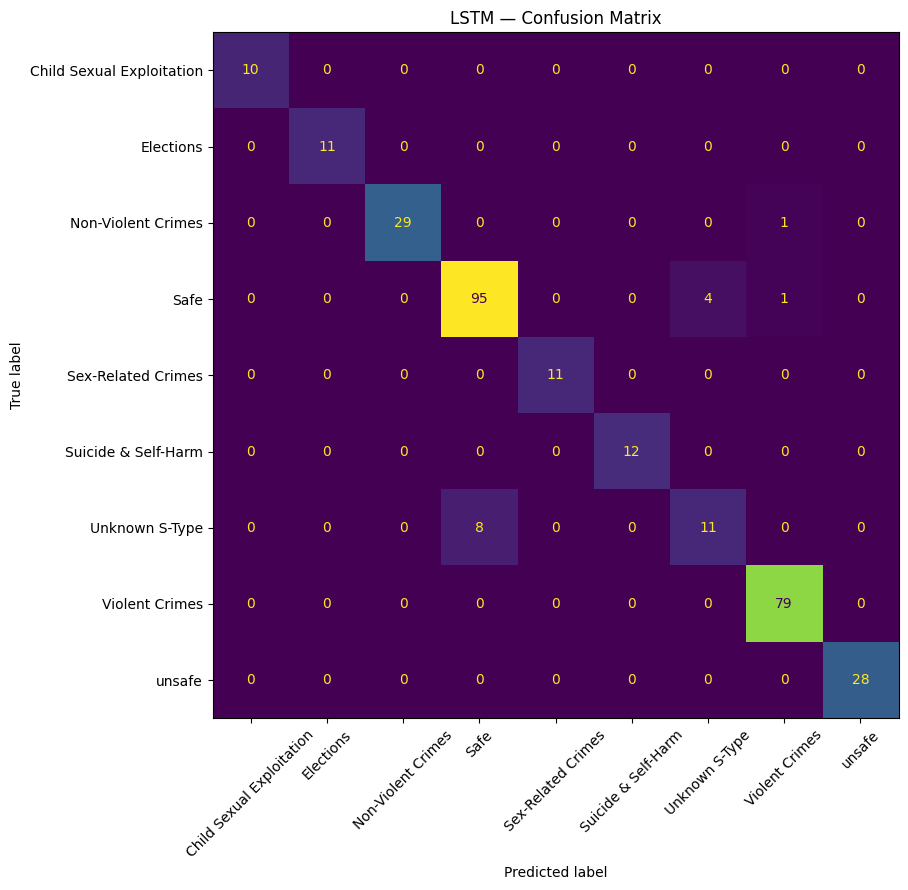


LSTM assignment target (Macro F1 >= 0.85): PASS


In [21]:
# ============================================================
# LSTM TEST EVALUATION
# ============================================================

lstm_metrics, lstm_predictions = evaluate_model(
    lstm_model,
    X_test,
    y_test,
    model_name="LSTM",
    file_prefix="lstm"
)

lstm_pass = (
    lstm_metrics["macro_f1"]
    >=
    LSTM_F1_TARGET
)

print(
    "\nLSTM assignment target "
    f"(Macro F1 >= {LSTM_F1_TARGET:.2f}):",
    "PASS" if lstm_pass else "NOT YET"
)

## LSTM Submission Summary

The LSTM is evaluated using Accuracy, Macro F1, Weighted F1,
a full classification report, training curves, and a confusion matrix.

The primary assignment metric is **Macro F1** because the dataset is imbalanced
and Macro F1 gives equal importance to every class.

The accompanying `LSTM_Results.pdf` contains the final training results and
the documented dataset limitations.

In [ ]:
# ============================================================
# SAVE LSTM REPRODUCIBILITY ARTIFACTS
# ============================================================

# The best LSTM model is already saved by ModelCheckpoint as:
# /content/cellula_lstm.keras

with open("/content/lstm_tokenizer.json", "w", encoding="utf-8") as file:
    file.write(tokenizer.to_json())

lstm_label_mapping = {
    str(class_id): label
    for class_id, label in enumerate(label_encoder.classes_)
}

with open("/content/lstm_label_mapping.json", "w", encoding="utf-8") as file:
    json.dump(lstm_label_mapping, file, indent=2)

print("LSTM submission artifacts are ready.")
print("Model: /content/cellula_lstm.keras")
print("Tokenizer: /content/lstm_tokenizer.json")
print("Label mapping: /content/lstm_label_mapping.json")